<a href="https://colab.research.google.com/github/nav-lak/python_library/blob/main/z_score_on_multiple_columns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import seaborn as sns
df = pd.DataFrame({
    "salary": [20000, 22000, 21000, 20500, 23000, 100000],
    "age":    [22, 23, 24, 22, 23, 60],
    "score":  [65, 70, 68, 66, 69, 95]
})

<Axes: >

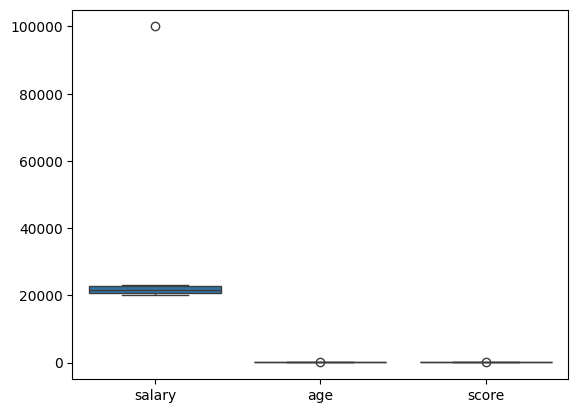

In [42]:
sns.boxplot(df)

In [43]:
u=df.mean()

In [44]:
u

,0
salary,34416.666667
age,29.000000
score,72.166667


In [45]:
std=df.std()
std

,0
salary,32147.187539
age,15.205262
score,11.338724


In [46]:
cols = ["salary", "age", "score"]
z_score=(df[cols]-u)/std

In [47]:
print("z_score of each columns :")
z_score

z_score of each columns :


,salary,age,score
0,-0.448458,-0.460367,-0.632052
1,-0.386244,-0.394600,-0.191086
2,-0.417351,-0.328834,-0.367472
3,-0.432905,-0.460367,-0.543859
4,-0.355137,-0.394600,-0.279279
5,2.040096,2.038768,2.013748


In [55]:
# identify outlier rows (|z| > 2)
outlier_rows = (z_score.abs() >2 ).any(axis=1)
outlier_rows


,0
0,False
1,False
2,False
3,False
4,False
5,True


In [57]:
# remove outliers
df_clean = df[~outlier_rows]

print(df_clean)

   salary  age  score
0   20000   22     65
1   22000   23     70
2   21000   24     68
3   20500   22     66
4   23000   23     69


In [49]:
print(df)

   salary  age  score
0   20000   22     65
1   22000   23     70
2   21000   24     68
3   20500   22     66
4   23000   23     69
5  100000   60     95


<Axes: >

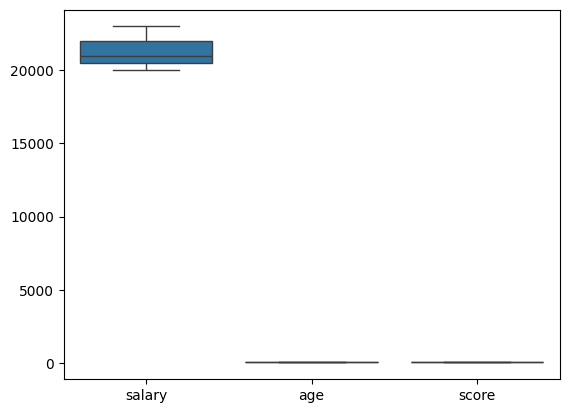

In [58]:
# boxplot after removing outlier
sns.boxplot(df_clean)